# Titanic Data Exploration Practice

Notebook ini dibuat untuk latihan melakukan **Exploratory Data Analysis (EDA)** menggunakan pustaka dasar Python.

### Library yang digunakan:
*   `pandas`: Untuk manipulasi data tabular
*   `numpy`: Untuk operasi statistik dan array
*   `matplotlib.pyplot`: Untuk visualisasi data dasar
*   `seaborn`: Untuk visualisasi data statistik yang lebih menarik

## 1. Import Libraries
Langkah pertama adalah mengimpor semua library yang dibutuhkan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset
Kita memuat data dari berkas `titanic.csv` di folder `dataset/`.

In [2]:
# Membaca data
df = pd.read_csv('https://raw.githubusercontent.com/mpfordreamer/library-practice/main/dataset/titanic.csv')
print("✅ Data loaded successfully!")
print("Shape (Baris, Kolom):", df.shape)

✅ Data loaded successfully!
Shape (Baris, Kolom): (418, 12)


In [3]:
# [Opsional] Menyeragamkan nama kolom menjadi huruf kecil semua agar tidak KeyError
df.columns = df.columns.str.lower()
print("Daftar Kolom Baru:", df.columns.tolist())

Daftar Kolom Baru: ['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


## 3. Assessing Data
Melihat struktur dasar data, tipe data, dan nilai null.

In [4]:
# Melihat 5 data teratas
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Cek Nilai Null dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  418 non-null    int64  
 1   survived     418 non-null    int64  
 2   pclass       418 non-null    int64  
 3   name         418 non-null    object 
 4   sex          418 non-null    object 
 5   age          332 non-null    float64
 6   sibsp        418 non-null    int64  
 7   parch        418 non-null    int64  
 8   ticket       418 non-null    object 
 9   fare         417 non-null    float64
 10  cabin        91 non-null     object 
 11  embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
# Statistik Deskriptif untuk kolom numerik
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 4. Exploratory Data Analysis (EDA)

### A. Univariate Analysis (Satu Variabel)
Melihat distribusi nilai pada satu kolom.

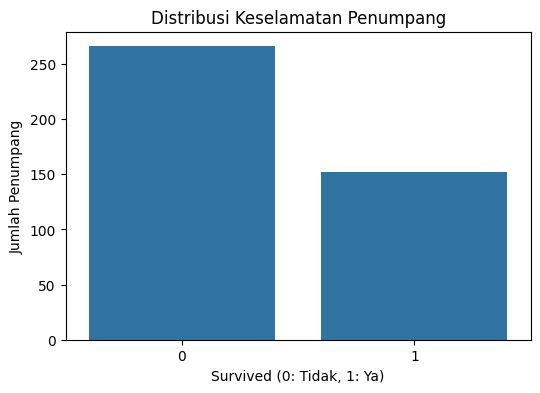

In [7]:
# Visualisasi Jumlah Korban Selamat (0 = Tidak, 1 = Ya)
plt.figure(figsize=(6, 4))
sns.countplot(df, x='survived')
plt.title('Distribusi Keselamatan Penumpang')
plt.xlabel('Survived (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Penumpang')
plt.show()

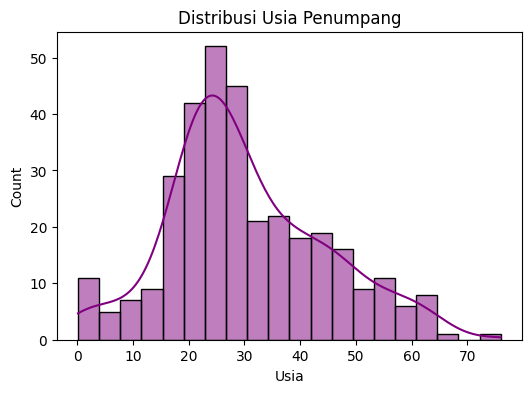

In [8]:
# Distribusi Usia (Age) menggunakan histogram
plt.figure(figsize=(6, 4))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='purple')
plt.title('Distribusi Usia Penumpang')
plt.xlabel('Usia')
plt.ylabel('Count')
plt.show()

### B. Bivariate Analysis (Dua Variabel)
Menganalisis hubungan antar variabel, khususnya dengan label keselamatan (`survived`).

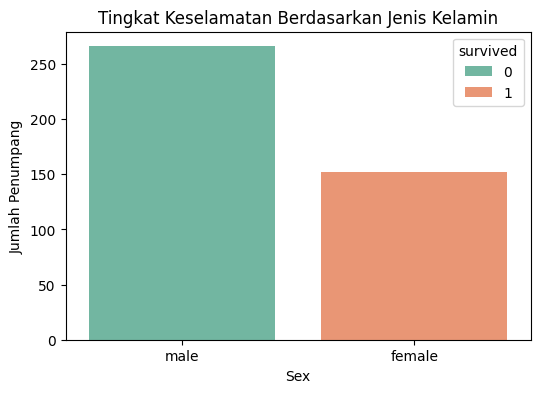

In [9]:
# Tingkat Keselamatan berdasarkan Gender (Sex)
plt.figure(figsize=(6, 4))
sns.countplot(df, x='sex', hue='survived', palette='Set2')
plt.title('Tingkat Keselamatan Berdasarkan Jenis Kelamin')
plt.xlabel('Sex')
plt.ylabel('Jumlah Penumpang')
plt.show()

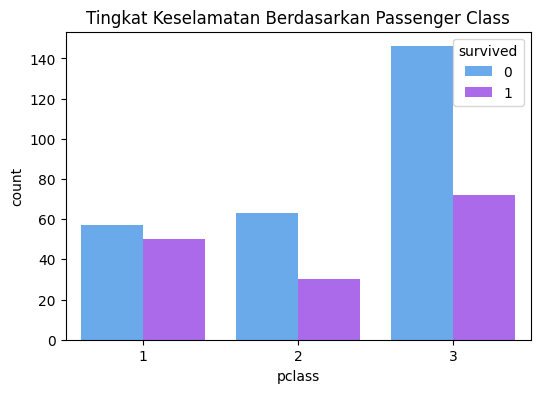

In [10]:
# Tingkat Keselamatan berdasarkan Kelas Penumpang (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(df, x='pclass', hue='survived', palette='cool')
plt.title('Tingkat Keselamatan Berdasarkan Passenger Class')
plt.show()

## 5. Matriks Korelasi
Melihat kekuatan hubungan antar kolom numeris.

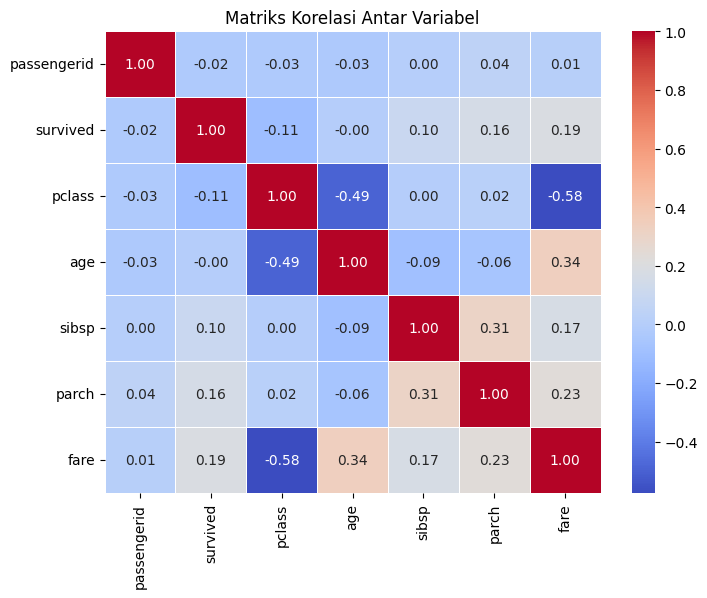

In [11]:
# Mengambil kolom numerik saja
numeris = df.select_dtypes(include=['number'])

# Heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(numeris.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Antar Variabel')
plt.show()